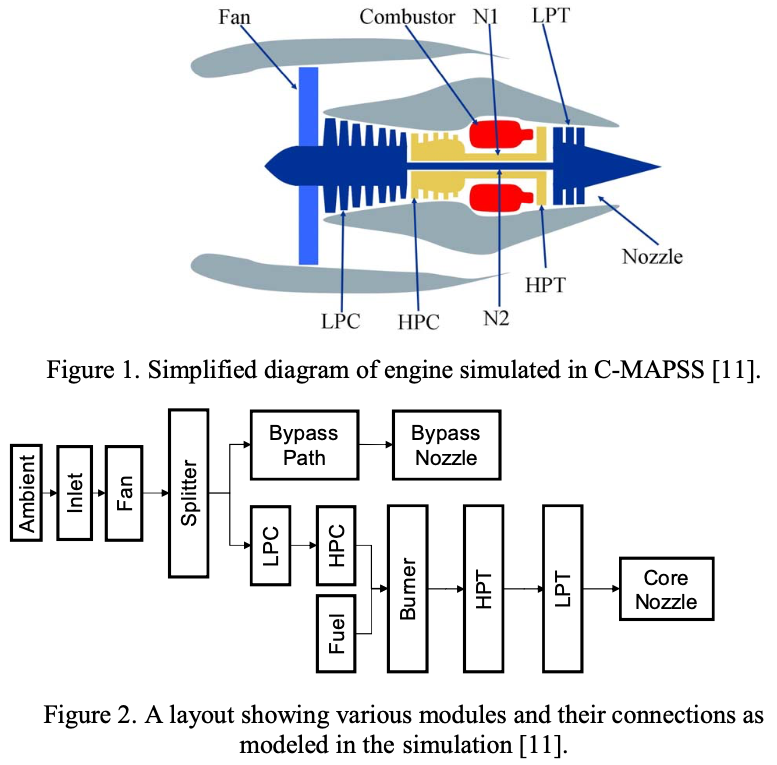

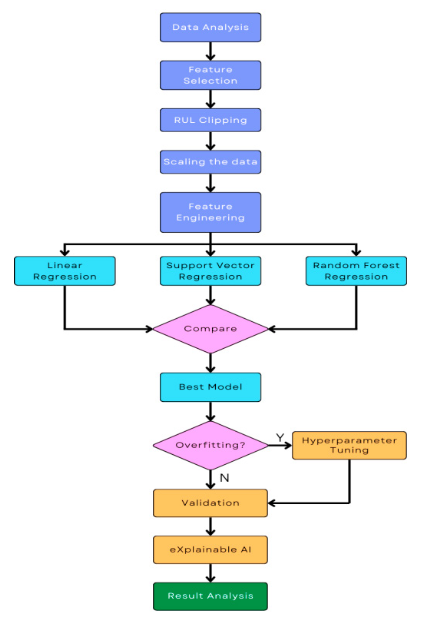

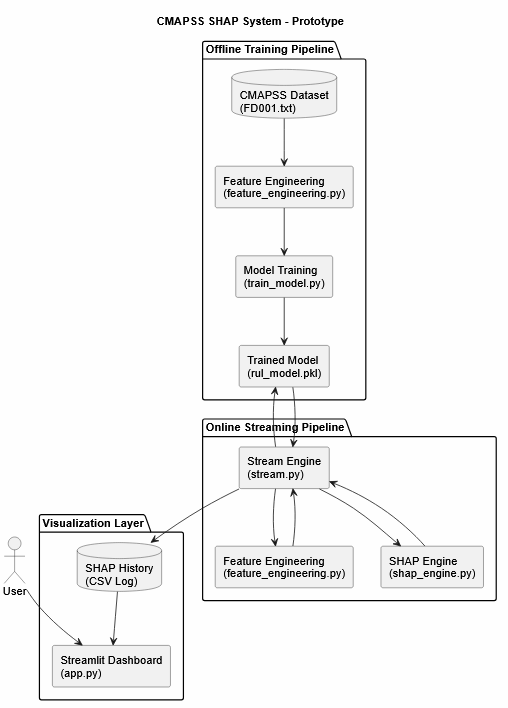

##Imports

In [ ]:
pip install lifelines

In [ ]:
import pandas as pd
import numpy as np
from copy import deepcopy

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Data preparation

In [ ]:
index_names = ['unit_num', 'time_cycles']
setting_names = ['setting1', 'setting2', 'setting3']
sensor_names = ['sensor{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
test = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
y_test = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=["RUL"])

train.head()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6883/1065462577.py:6: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_6883/1065462577.py:7: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
/tmp/ipykernel_6883/1065462577.py:8: SyntaxWarning: invalid escape sequence '\s'
  y_test = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=["RUL"])


,unit_num,time_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
def add_remaining_useful_life(df):

    n_cycles = df.groupby("unit_num")["time_cycles"].max()

    df = df.copy()

    df = df.merge(
        n_cycles.rename("n_cycles"),
        left_on="unit_num",
        right_index=True
    )

    df["RUL"] = df["n_cycles"] - df["time_cycles"]

    df = df.drop("n_cycles", axis=1)

    return df

train = add_remaining_useful_life(train)
train[index_names + ['RUL']]

,unit_num,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
...,...,...,...
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1


##Plot sensor behaviour with RUL

In [ ]:
min_rul = train.RUL.min()
max_rul = train.RUL.max()

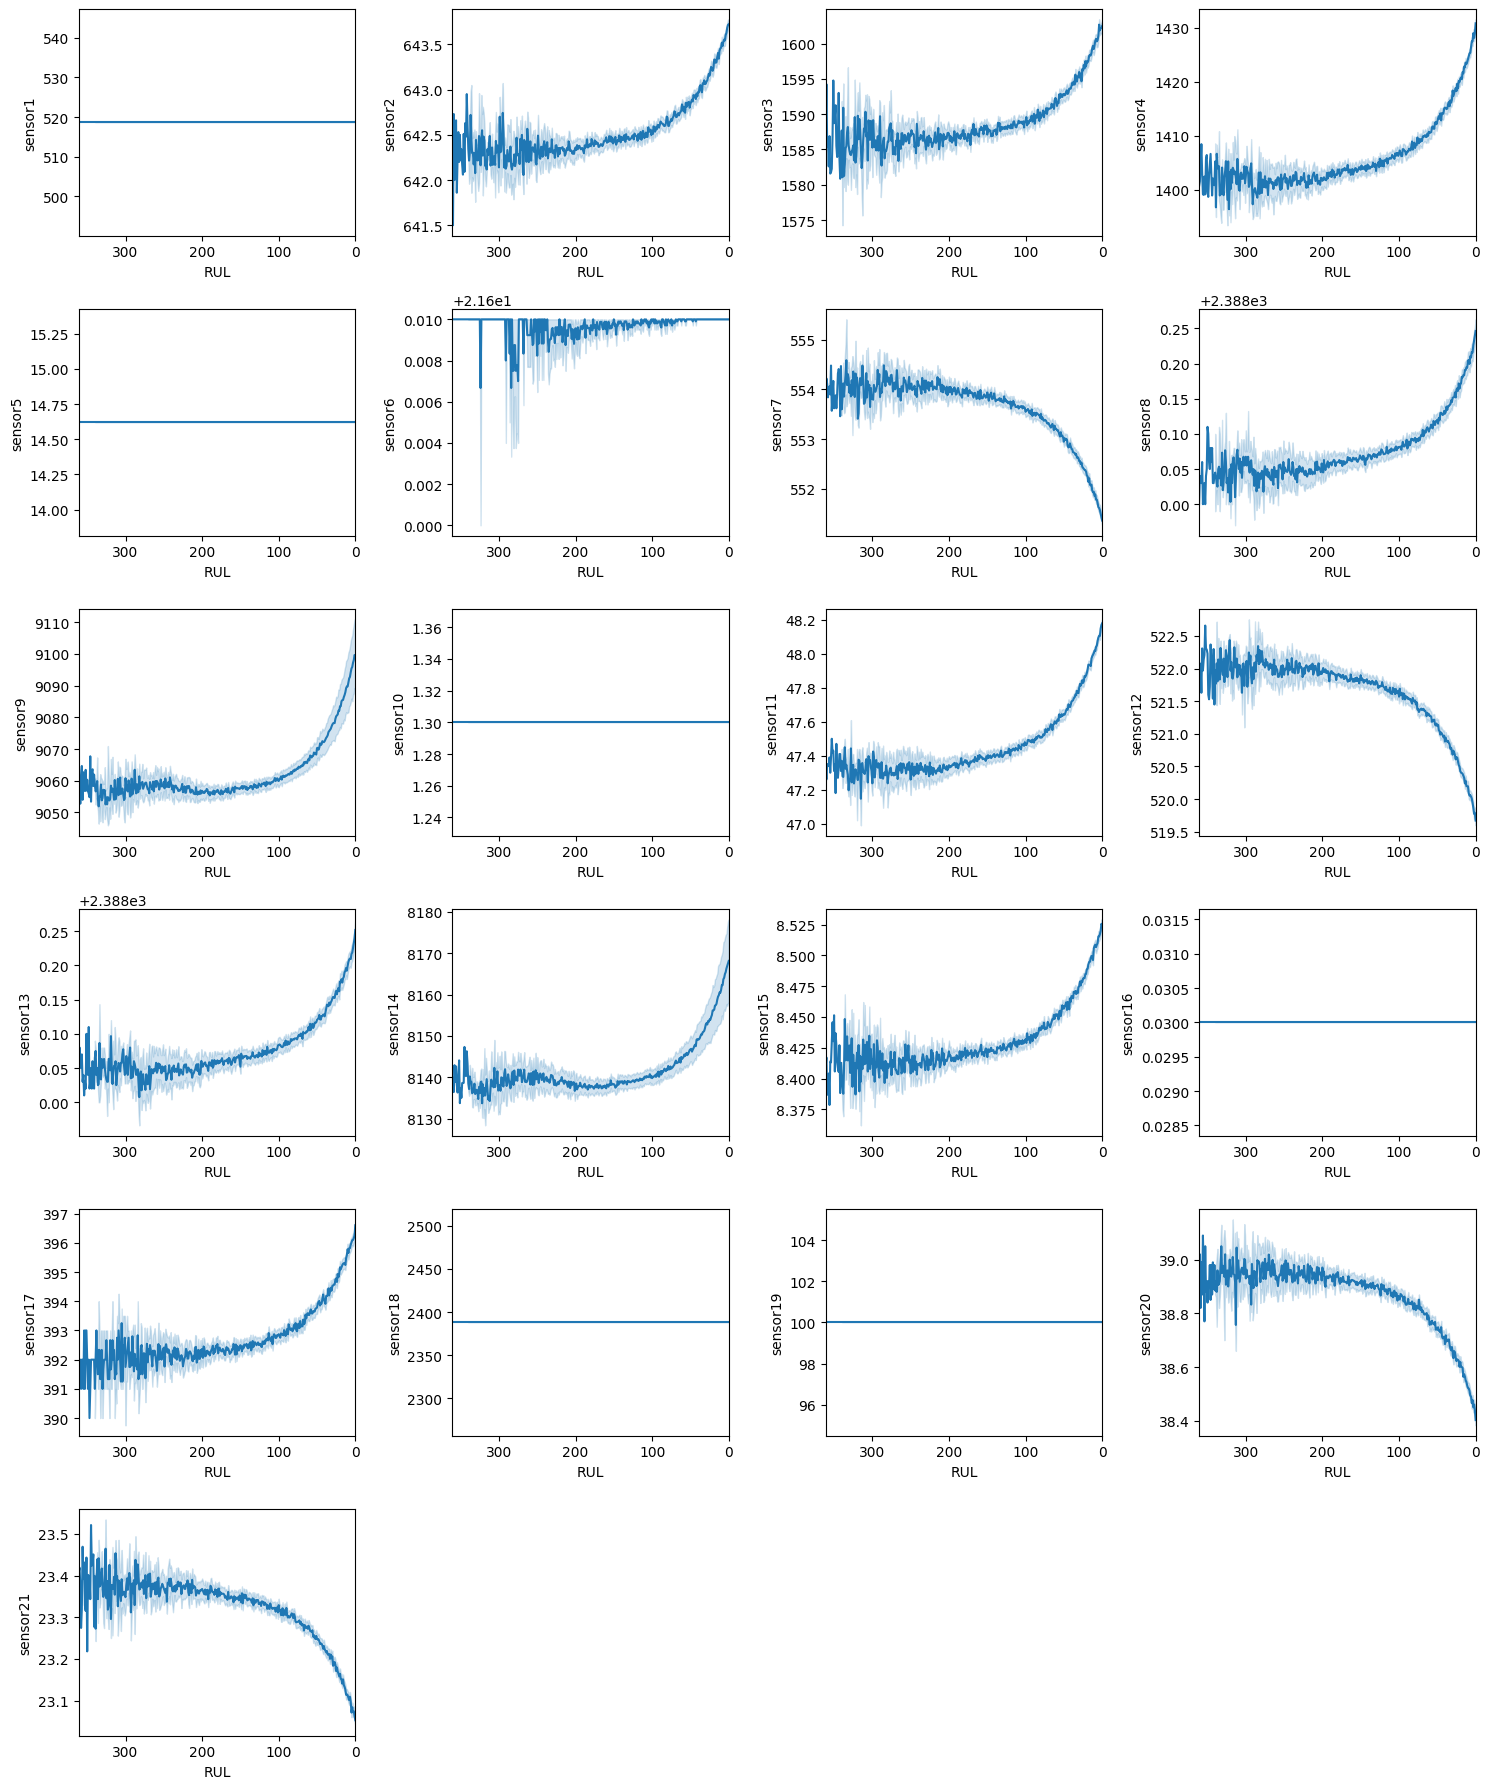

In [ ]:
sensor_names = [f"sensor{i+1}" for i in range(21)]

fig, axes = plt.subplots(6, 4, figsize=(15, 18))

for i, s in enumerate(sensor_names):
    sns.lineplot(data=train, x="RUL", y=s, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_xlim(max_rul, min_rul)

axes.flat[-3].set_visible(False)
axes.flat[-2].set_visible(False)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()



In [ ]:
train[["sensor9", "sensor14"]].corr()

,sensor9,sensor14
sensor9,1.000000,0.963157
sensor14,0.963157,1.000000


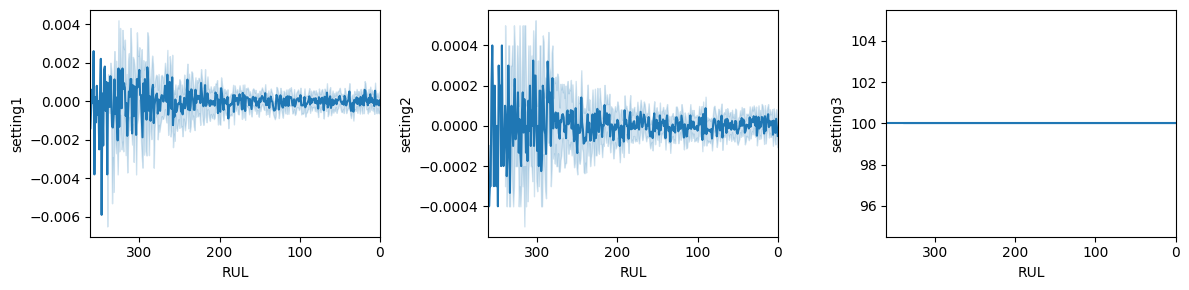

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for i, s in enumerate(setting_names):
    sns.lineplot(data=train, x="RUL", y=s, ax=axes[i])
    axes[i].set_xlim(max_rul, min_rul)

plt.tight_layout()
plt.show()

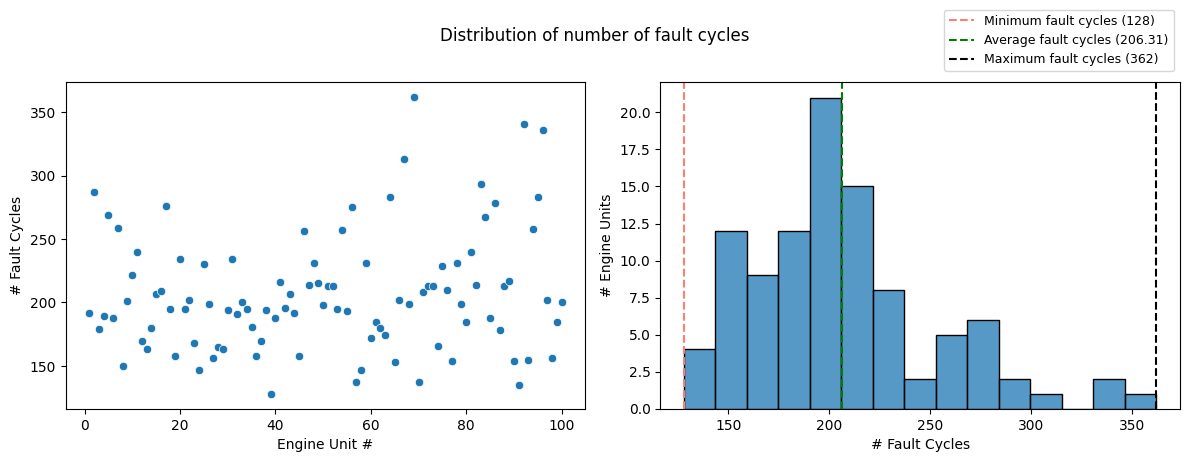

In [ ]:
n_cycles = train[index_names].groupby('unit_num').count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=n_cycles, x="unit_num", y="time_cycles", ax=axes[0])

hist = sns.histplot(data=n_cycles, x="time_cycles", edgecolor='k', ax=axes[1], bins=15)
hist.axvline(n_cycles.time_cycles.min(), color="salmon",
             label=f"Minimum fault cycles ({n_cycles.time_cycles.min()})", ls="--")
hist.axvline(n_cycles.time_cycles.mean(), color="green",
             label=f"Average fault cycles ({round(n_cycles.time_cycles.mean(), 2)})", ls="--")
hist.axvline(n_cycles.time_cycles.max(), color="black",
             label=f"Maximum fault cycles ({n_cycles.time_cycles.max()})", ls="--")

axes[0].set_ylabel("# Fault Cycles")
axes[0].set_xlabel("Engine Unit #")

axes[1].set_ylabel("# Engine Units")
axes[1].set_xlabel("# Fault Cycles")

plt.tight_layout()

axes[1].legend(ncol=1, loc="upper right", bbox_to_anchor=[1, 1.24], fontsize=9)
fig.suptitle("Distribution of number of fault cycles", y=1.1)

plt.show()



##Feature Extraction

visual interpretation

In [ ]:
del_cols = ["setting1", "setting2", "setting3","sensor1", "sensor5", "sensor6", "sensor10", "sensor14", "sensor16", "sensor18", "sensor19"]
train = train.drop(del_cols, axis=1)
test = test.drop(del_cols, axis=1)
remaining_cols = train.columns.tolist()
print(remaining_cols)

['unit_num', 'time_cycles', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'RUL']


automatic

In [ ]:
low_var_cols = [c for c in train.columns if train[c].std() < 1e-3]
print(low_var_cols)

['setting2', 'setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


In [ ]:
na = train.isna().empty
if na:
  train = train.fillna(method="ffill")
  print("Filled missing data")
else:
  print("No missing data. Continue")

No missing data. Continue


##Feature Engineering

In [ ]:
def slope(x):

    idx = np.arange(len(x))

    return np.polyfit(idx, x, 1)[0]

In [ ]:
window = 50
lags = [1,5,10]

for sensor in remaining_cols:

    if sensor == "RUL" or sensor=="unit_num" or sensor=="time_cycles":
        continue

    train[f"{sensor}_roll_mean"] = (
        train.groupby("unit_num")[sensor]
        .transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    )

    train[f"{sensor}_roll_std"] = (
        train.groupby("unit_num")[sensor]
        .transform(
            lambda x: x.rolling(window, min_periods=2).std()
        )
    )

    train[f"{sensor}_diff"] = (
        train.groupby("unit_num")[sensor]
        .diff()
    )

    train[f"{sensor}_pct_change"] = (
        train.groupby("unit_num")[sensor]
        .pct_change()
    )

    train[f"{sensor}_slope"] = (
    train.groupby("unit_num")[sensor]
    .transform(
        lambda x:
        x.rolling(20, min_periods=5)
        .apply(slope, raw=True)
    )
    )

    train[f"{sensor}_ewm"] = (
    train.groupby("unit_num")[sensor]
    .transform(lambda x: x.ewm(span=20).mean())
    )


In [ ]:
for sensor in remaining_cols:

    if sensor == "RUL" or sensor=="unit_num" or sensor=="time_cycles":
        continue

    test[f"{sensor}_roll_mean"] = (
        test.groupby("unit_num")[sensor]
        .transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    )

    test[f"{sensor}_roll_std"] = (
        test.groupby("unit_num")[sensor]
        .transform(
            lambda x: x.rolling(window, min_periods=2).std()
        )
    )

    test[f"{sensor}_diff"] = (
        test.groupby("unit_num")[sensor]
        .diff()
    )

    test[f"{sensor}_pct_change"] = (
        test.groupby("unit_num")[sensor]
        .pct_change()
    )

    test[f"{sensor}_slope"] = (
    test.groupby("unit_num")[sensor]
    .transform(
        lambda x:
        x.rolling(20, min_periods=5)
        .apply(slope, raw=True)
    )
    )

    test[f"{sensor}_ewm"] = (
    test.groupby("unit_num")[sensor]
    .transform(lambda x: x.ewm(span=20).mean())
    )


In [ ]:
train = train.dropna()
test = test.dropna()

In [ ]:
del_cols = ["sensor2", "sensor3", "sensor4","sensor7","sensor8", "sensor9", "sensor11", "sensor12", "sensor13", "sensor15", "sensor17", "sensor20", "sensor21"]
train = train.drop(del_cols, axis=1)
test = test.drop(del_cols, axis=1)
remaining_cols = train.columns.tolist()
print(remaining_cols)

['unit_num', 'time_cycles', 'RUL', 'sensor2_roll_mean', 'sensor2_roll_std', 'sensor2_diff', 'sensor2_pct_change', 'sensor2_slope', 'sensor2_ewm', 'sensor3_roll_mean', 'sensor3_roll_std', 'sensor3_diff', 'sensor3_pct_change', 'sensor3_slope', 'sensor3_ewm', 'sensor4_roll_mean', 'sensor4_roll_std', 'sensor4_diff', 'sensor4_pct_change', 'sensor4_slope', 'sensor4_ewm', 'sensor7_roll_mean', 'sensor7_roll_std', 'sensor7_diff', 'sensor7_pct_change', 'sensor7_slope', 'sensor7_ewm', 'sensor8_roll_mean', 'sensor8_roll_std', 'sensor8_diff', 'sensor8_pct_change', 'sensor8_slope', 'sensor8_ewm', 'sensor9_roll_mean', 'sensor9_roll_std', 'sensor9_diff', 'sensor9_pct_change', 'sensor9_slope', 'sensor9_ewm', 'sensor11_roll_mean', 'sensor11_roll_std', 'sensor11_diff', 'sensor11_pct_change', 'sensor11_slope', 'sensor11_ewm', 'sensor12_roll_mean', 'sensor12_roll_std', 'sensor12_diff', 'sensor12_pct_change', 'sensor12_slope', 'sensor12_ewm', 'sensor13_roll_mean', 'sensor13_roll_std', 'sensor13_diff', 'sens

raw sensors
+ rolling mean
+ rolling std
+ diff
+ lag
+ slope
+ ewn

##Clipping RUL
since engines develop fault over time (bend in graphs) -> start RUL as constant and decline linearly after time

In [ ]:
X_train = train.drop(
    ["unit_num","time_cycles", "RUL"],
    axis=1
    )
y_train = train["RUL"]

test_last = test.groupby("unit_num").last().reset_index()
X_test = test_last.drop(
    ["unit_num", "time_cycles"],
    axis=1
)
y_test = y_test.iloc[:,0]

X_train.shape, X_test.shape

((20631, 13), (100, 13))

In [ ]:
y_train = y_train.clip(upper=125)
y_test = y_test.clip(upper=125)

##Scaling

In [ ]:
feature_cols = X_train.columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

##Model Selection

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

models = []

lr = LinearRegression()
models.append(lr)

knn = KNeighborsRegressor(n_neighbors=5)
models.append(knn)

svr = SVR()
models.append(svr)

rf = RandomForestRegressor(n_estimators=100)
models.append(rf)

xgb = XGBRegressor()
models.append(xgb)

lgbm = lgb.LGBMRegressor()
models.append(lgbm)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

class Models:
    def __init__(self, X_train, Y_train, X_test, Y_test, models):
        self.X_train = X_train
        self.X_test = X_test
        self.Y_train = Y_train
        self.Y_test = Y_test
        self.models = models

    def fit(self):

        rmse = []
        mae = []
        r2 = []
        time_window = []

        for model in self.models:

            start = time.time()

            model.fit(self.X_train,self.Y_train)
            preds = model.predict(self.X_test)

            rm = np.sqrt(mean_squared_error(self.Y_test,preds))
            m = mean_absolute_error(self.Y_test,preds)
            r = r2_score(self.Y_test,preds)

            stop = time.time()

            rmse.append(rm)
            mae.append(m)
            r2.append(r)
            time_window.append((stop-start))

        self.outputM = pd.DataFrame({'Model':self.models,'RMSE':rmse, "MAE":mae, "R2": r2, "Speed (s)":time_window})

    def results(self):
        model = self.outputM

        model = model.sort_values(by="RMSE",ascending=True)

        model["Model"] = model["Model"].astype(str).str.split("(").str[0]

        return model

without Feature Engineering

In [ ]:
testModels = [lr, knn, svr, rf, xgb, lgbm]

classifications = Models(X_train_scaled, y_train, X_test_scaled, y_test, testModels)
classifications.fit()
classifications.results()

,Model,RMSE,MAE,R2,Speed (s)
5,LGBMRegressor,17.492734,12.450772,0.809451,0.264806
3,RandomForestRegressor,17.556093,12.380000,0.808069,27.371016
1,KNeighborsRegressor,17.709670,13.030000,0.804696,0.207494
4,XGBRegressor,18.271200,13.161229,0.792114,0.380000
2,SVR,19.052105,13.040410,0.773965,22.558314
0,LinearRegression,21.026819,16.809250,0.724680,0.042729


with Feature Engineering

In [ ]:
testModels = [lr, knn, svr, rf, xgb, lgbm]

classifications = Models(X_train_scaled, y_train, X_test_scaled, y_test, testModels)
classifications.fit()
classifications.results()

,Model,RMSE,MAE,R2,Speed (s)
5,LGBMRegressor,15.217566,11.142070,0.855795,1.962724
3,RandomForestRegressor,15.574565,11.238800,0.848950,213.762967
2,SVR,15.607267,12.208424,0.848315,38.666633
4,XGBRegressor,15.811710,12.237422,0.844315,4.622622
0,LinearRegression,16.339638,13.506536,0.833745,0.106872
1,KNeighborsRegressor,18.498540,13.276000,0.786909,0.078788


only Feature Engineering

In [ ]:
testModels = [lr, knn, svr, rf, xgb, lgbm]

classifications = Models(X_train_scaled, y_train, X_test_scaled, y_test, testModels)
classifications.fit()
classifications.results()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18915
[LightGBM] [Info] Number of data points in the train set: 20231, number of used features: 78
[LightGBM] [Info] Start training from score 86.074638


,Model,RMSE,MAE,R2,Speed (s)
0,LinearRegression,14.735933,11.622656,0.864779,0.111371
4,XGBRegressor,15.094554,10.940359,0.858117,9.640828
5,LGBMRegressor,15.721918,11.192072,0.846078,4.773086
2,SVR,15.886067,12.299564,0.842847,47.187412
3,RandomForestRegressor,16.367567,11.742500,0.833176,255.526584
1,KNeighborsRegressor,19.814146,13.986000,0.755521,0.129361


##Prepare RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

In [ ]:
pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 16.691817208577014
MAE : 11.934864774838493
R2  : 0.8265007780999691


##Visualization

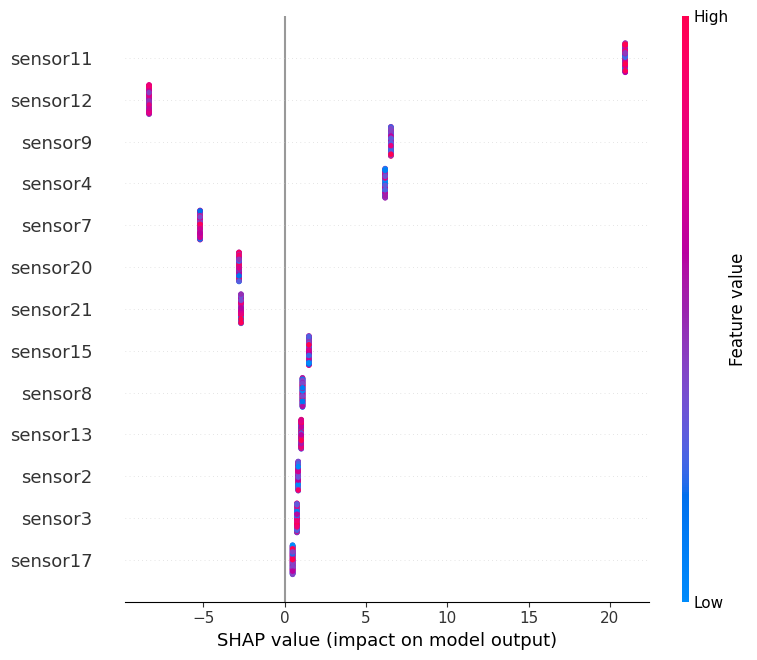

In [ ]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled)

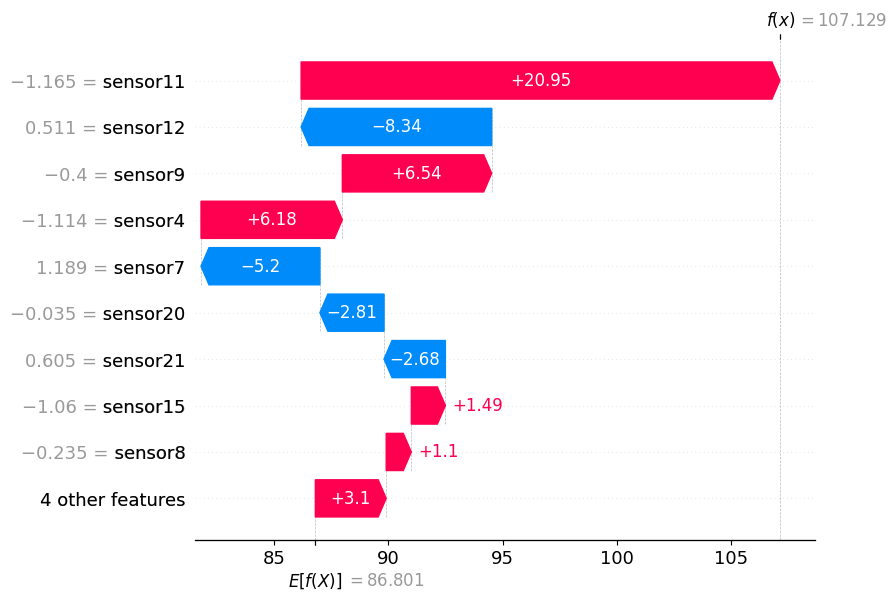

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

dependency of sensor ~ RUL

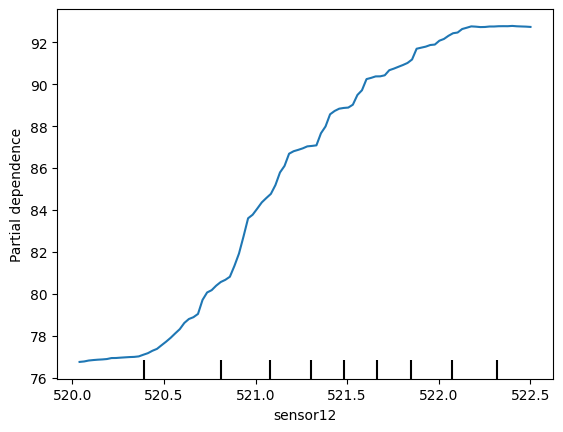

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    ["sensor12"]
)

plt.show()

Partial Dependence Plot (PDP): shows how one feature affects the model on average (global effect, other features are averaged out)

##Prepare LinearRegression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
pred = lr_model.predict(X_test_scaled)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 14.735932716652904
MAE : 11.622655605517664
R2  : 0.8647785617245997


##Visualiszation

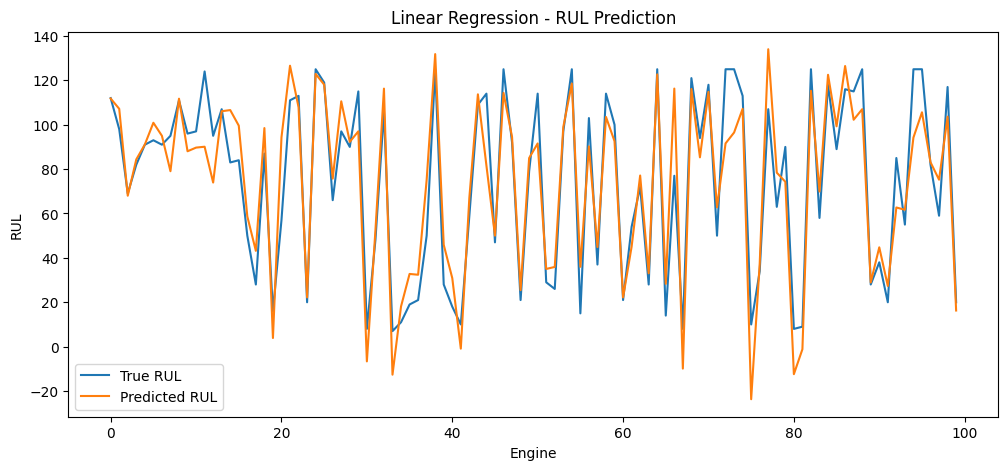

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="True RUL")
plt.plot(pred, label="Predicted RUL")

plt.title("Linear Regression - RUL Prediction")
plt.xlabel("Engine")
plt.ylabel("RUL")
plt.legend()

plt.show()

positive increases RUL, negative decreases

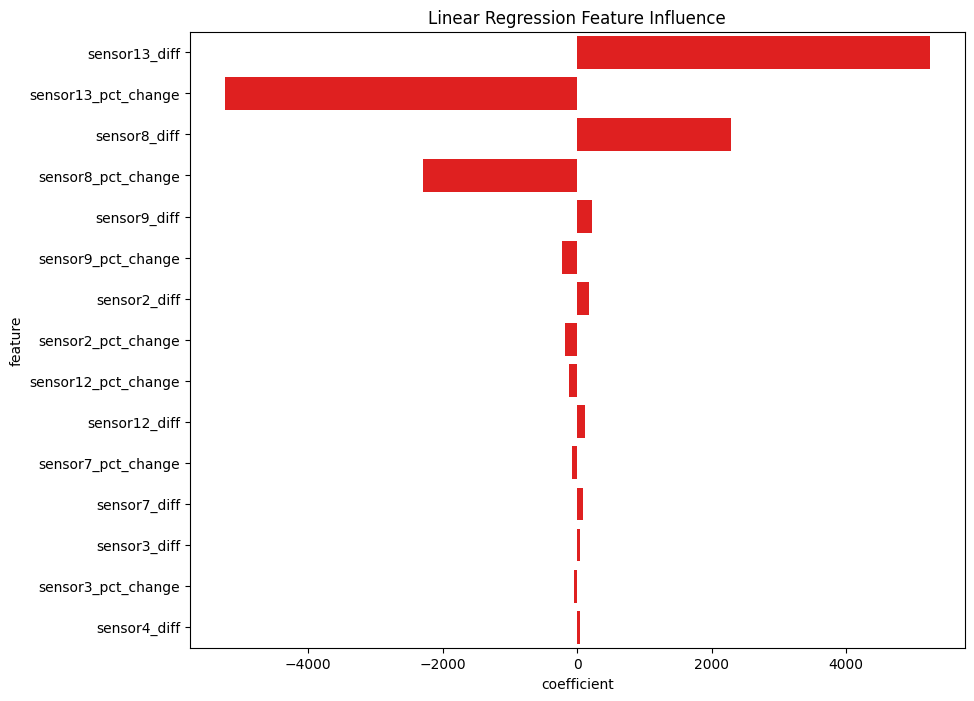

In [ ]:
coefs = lr_model.coef_

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": coefs
})

coef_df = coef_df.sort_values(
    by="coefficient",
    key=abs,
    ascending=False
)

import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=coef_df.head(15),
    x="coefficient",
    y="feature",
    color="red"
)

plt.title("Linear Regression Feature Influence")
plt.show()

- most common way for linear moedel explainability -> coeffs tell model change when change each input feat
- but value of coeffs depend on scale of input feat, thus magnitude not good measure

##Prepare LGBMRegressor

In [ ]:
from sklearn.model_selection import ParameterSampler

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "min_data_in_leaf": [10, 20, 50],
    "feature_fraction": [0.6, 0.8, 1.0],
    "bagging_fraction": [0.6, 0.8, 1.0]
}

samples = list(ParameterSampler(param_grid, n_iter=10, random_state=42))

In [ ]:
best_rmse = float("inf")
best_params = None

for p in samples:

    model = lgb.LGBMRegressor(
        **p,
        n_estimators=1000
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = p

    print(rmse, p)

15.845781814946744 {'num_leaves': 63, 'min_data_in_leaf': 50, 'max_depth': 5, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_fraction': 0.8}
15.733978509730864 {'num_leaves': 127, 'min_data_in_leaf': 20, 'max_depth': 5, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 1.0}
14.840247302976502 {'num_leaves': 15, 'min_data_in_leaf': 50, 'max_depth': 15, 'learning_rate': 0.03, 'feature_fraction': 0.8, 'bagging_fraction': 0.8}
16.216584263400247 {'num_leaves': 63, 'min_data_in_leaf': 50, 'max_depth': 15, 'learning_rate': 0.05, 'feature_fraction': 0.6, 'bagging_fraction': 1.0}
16.322261045316562 {'num_leaves': 63, 'min_data_in_leaf': 10, 'max_depth': 10, 'learning_rate': 0.1, 'feature_fraction': 1.0, 'bagging_fraction': 0.8}
15.651049875875874 {'num_leaves': 127, 'min_data_in_leaf': 10, 'max_depth': 15, 'learning_rate': 0.05, 'feature_fraction': 1.0, 'bagging_fraction': 0.8}
15.630741275747766 {'num_leaves': 15, 'min_data_in_leaf': 50, 'max_depth': 15, 'learning_r

In [ ]:
from sklearn.model_selection import GroupKFold
import lightgbm as lgb
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 15,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "seed": 42
}

gkf = GroupKFold(n_splits=5)

rmse_scores = []
mae_scores = []
r2_scores = []

models = []

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X_train_scaled, y_train, groups=train["unit_num"])
):

    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=2000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae = mean_absolute_error(y_val, pred)
    r2 = r2_score(y_val, pred)

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)

    models.append(model)

    print(f"Fold {fold}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}")

print("\n===== CROSS VALIDATION RESULTS =====")
print("RMSE:", np.mean(rmse_scores))
print("MAE :", np.mean(mae_scores))
print("R2  :", np.mean(r2_scores))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001915 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2412
[LightGBM] [Info] Number of data points in the train set: 16511, number of used features: 13
[LightGBM] [Info] Start training from score 86.843619
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[248]	valid_0's rmse: 19.1955
Fold 0: RMSE=19.20, MAE=14.26, R2=0.79
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2413
[LightGBM] [Info] Number of data points in the train set: 16498, number of used features: 13
[LightGBM] [Info] Start training from score 86.813553
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[192]	valid_0's rmse: 18.9172
Fold 1: RMSE=18.92, MAE

In [ ]:
final_model = lgb.LGBMRegressor(**params)
final_model.fit(X_train_scaled, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, 

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              learning_rate=0.03, metric='rmse', min_data_in_leaf=50,
              num_leaves=15, objective='regression', seed=42)

In [ ]:
train_pred = final_model.predict(X_train_scaled)
test_pred = final_model.predict(X_test_scaled)

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


##Visualization

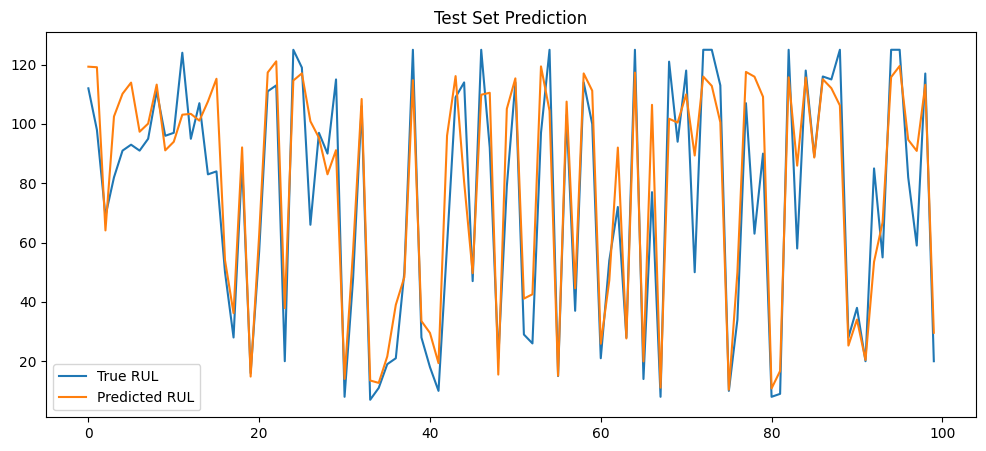

In [ ]:
def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True RUL")
    plt.plot(y_pred, label="Predicted RUL")
    plt.title(title)
    plt.legend()
    plt.show()

plot_results(y_test, test_pred, "Test Set Prediction")

Waterfall modell for concrete machine at concrete time cycle:
  - base line = average model output (all samples)
  - feats pushing prediction higher shown in red (healthy)
  - feats lowering prediction in blue (wear)

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import shap

explainer = shap.Explainer(final_model)
shap_values = explainer(X_test_scaled)

dropdown = widgets.Dropdown(
    options=list(range(len(X_test_scaled))),
    value=0,
    description='Sample:',
)

def show_shap(idx):

    print("Engine:", test_last.iloc[idx]["unit_num"])

    pred = final_model.predict(
        X_test_scaled.iloc[[idx]]
    )[0]

    print("Predicted RUL:", round(pred, 2))

    print("True RUL:", y_test.iloc[idx].squeeze())

    shap.plots.waterfall(shap_values[idx])


widgets.interactive(show_shap, idx=dropdown)



interactive(children=(Dropdown(description='Sample:', options=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 1…

- SHAP plot: A plot of many points where each point is one prediction. It shows how much a feature pushes the prediction up or down for each case.
- The PDP line is like the overall curve, while SHAP points are the individual deviations around that curve (background prior expectation (E[f(X)] and add features to reach current output model)
→ SHAP “breaks” the PDP into per-sample contributions

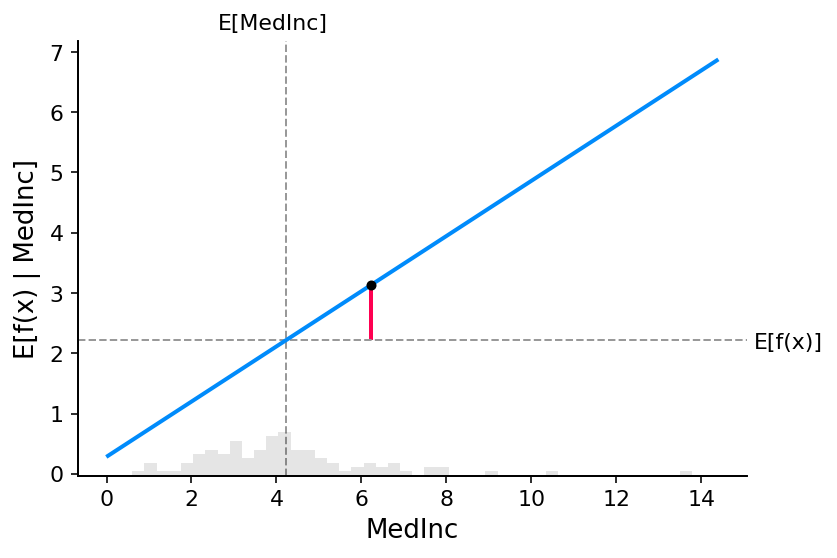

many force plots together, rotate by 90 degrees and stack horizonatlly -> for entire dataset

In [ ]:
# visualize all the training set predictions
shap.initjs()
shap.plots.force(shap_values)

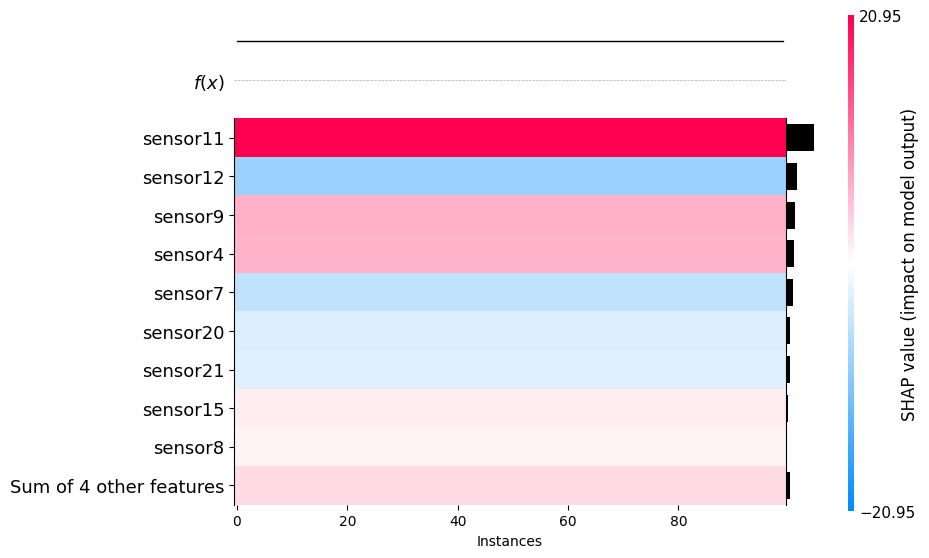

<Axes: xlabel='Instances'>

In [ ]:
shap.plots.heatmap(shap_values)

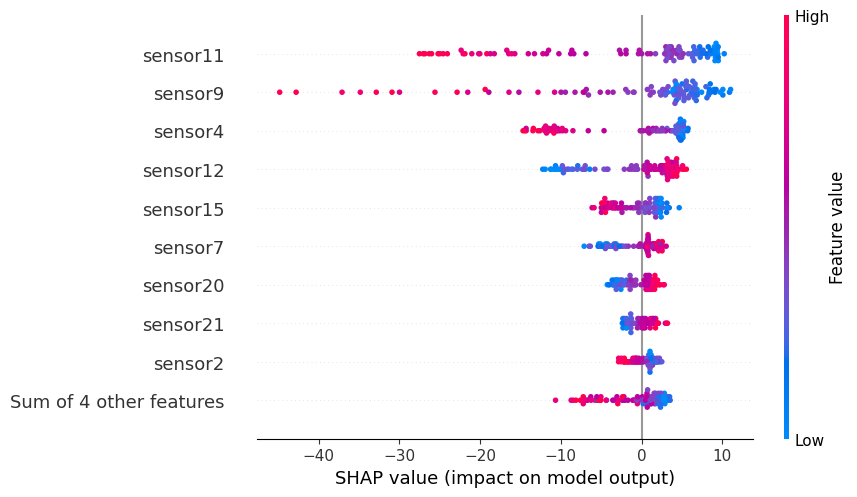

In [ ]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

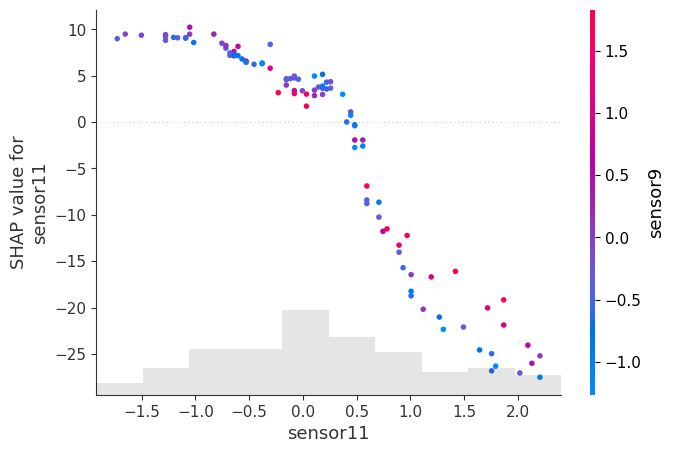

In [ ]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(shap_values[:, "sensor11"], color=shap_values)

In [ ]:
!pip install xai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 5.7 MB/s eta 0:00:00


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=90299c9ec9c4006189bddeadc86a06b4568231addb800ce97556906e021df7c5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode="regression"
)

In [ ]:
i = 0  # Test-Index

exp = explainer.explain_instance(
    data_row=X_test_scaled.iloc[i].values,
    predict_fn=final_model.predict,
    num_features=10
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


In [ ]:
exp.show_in_notebook(show_table=True)

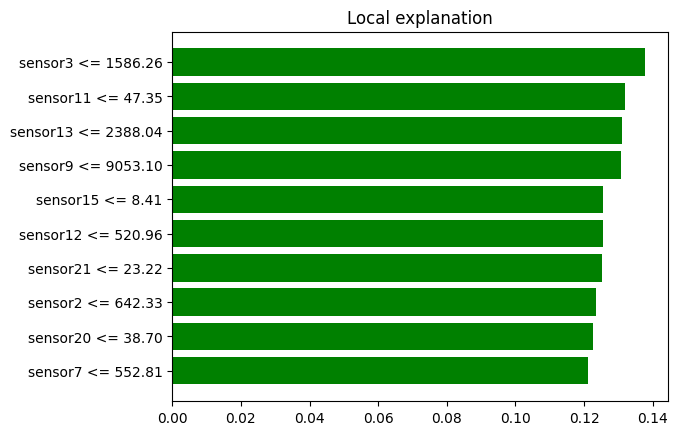

In [ ]:
fig = exp.as_pyplot_figure()

In [ ]:
def get_metrics(y, p, label):
    mae = mean_absolute_error(y, p)
    rmse = mean_squared_error(y, p)
    r2 = r2_score(y, p)
    print(f'----- {label} -----\nRMSE: {round(rmse, 2)}\nMAE : {round(mae, 2)}\nR2  : {round(r2, 2)}\n')

In [ ]:
def train_and_plot(model, X_train, y_train, X_test, y_test, plot):
    model = deepcopy(model)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    get_metrics(y_train, y_pred_train, "Train")

    y_pred_test = model.predict(X_test)
    get_metrics(y_test, y_pred_test, "Test")

    if plot:
        plt.figure(figsize=(5, 5))

        sns.regplot(x=y_test.RUL.values, y=y_pred_test, color='red', label="Linear fit")
        sns.scatterplot(x=y_test.RUL.values, y=y_pred_test, edgecolor='k')

        plt.xlabel("Actual RUL")
        plt.ylabel("Predicted RUL")
        plt.title("Actual vs predicted RUL for test set")

        plt.show()

    return model

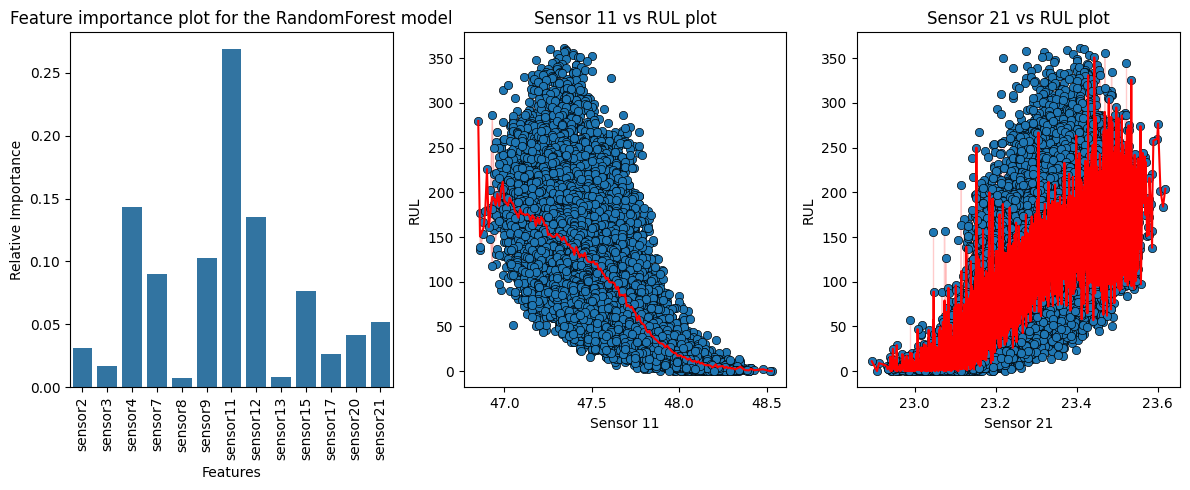

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
cols =X_train.columns.tolist()

sns.barplot(x=cols, y=rf.feature_importances_, ax=axes[0])

sns.lineplot(x=train["sensor11"], y=y_train, color='red', ax=axes[1])
sns.scatterplot(x=train["sensor11"], y=y_train, edgecolor='k', ax=axes[1])

sns.lineplot(x=train["sensor21"], y=y_train, color='red', ax=axes[2])
sns.scatterplot(x=train["sensor21"], y=y_train, edgecolor='k', ax=axes[2])


axes[0].tick_params('x', labelrotation=90)
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Relative Importance")
axes[0].set_title("Feature importance plot for the RandomForest model")

axes[1].set_xlabel("Sensor 11")
axes[1].set_ylabel("RUL")
axes[1].set_title("Sensor 11 vs RUL plot")

axes[2].set_xlabel("Sensor 21")
axes[2].set_ylabel("RUL")
axes[2].set_title("Sensor 21 vs RUL plot")

plt.tight_layout()
plt.show()



#Survival Analysis

In [ ]:
train2 = train.copy()
train2['RUL'] = train2["RUL"].clip(upper=125)

train2.drop(del_cols[:-2], axis=1, inplace=True) #keep unit_num and time_cycles

##Add breakdown and start values

In [ ]:
train2["breakdown"] = 0

idx_last_record = train2.reset_index().groupby(by="unit_num")["index"].last()
train2.loc[idx_last_record, "breakdown"] = 1

print(train2)

       unit_num  time_cycles  sensor2  sensor3  sensor4  sensor7  sensor8  \
0             1            1   641.82  1589.70  1400.60   554.36  2388.06   
1             1            2   642.15  1591.82  1403.14   553.75  2388.04   
2             1            3   642.35  1587.99  1404.20   554.26  2388.08   
3             1            4   642.35  1582.79  1401.87   554.45  2388.11   
4             1            5   642.37  1582.85  1406.22   554.00  2388.06   
...         ...          ...      ...      ...      ...      ...      ...   
20626       100          196   643.49  1597.98  1428.63   551.43  2388.19   
20627       100          197   643.54  1604.50  1433.58   550.86  2388.23   
20628       100          198   643.42  1602.46  1428.18   550.94  2388.24   
20629       100          199   643.23  1605.26  1426.53   550.68  2388.25   
20630       100          200   643.85  1600.38  1432.14   550.79  2388.26   

       sensor9  sensor11  sensor12  sensor13  sensor15  sensor17  sensor20 

In [ ]:
from lifelines import WeibullAFTFitter
aft=WeibullAFTFitter()
aft.fit(train2, duration_col='time_cycles',event_col='breakdown',
       formula= "	sensor2 +	sensor3 +	sensor4 +	sensor7 +	sensor8 +	sensor9 +	sensor11 +	sensor12 +	sensor13 +	sensor15 +	sensor17 +	sensor20 +	sensor21")

<lifelines.WeibullAFTFitter: fitted with 20631 total observations, 20531 right-censored observations>

In [ ]:
aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 20631 total observations, 20531 right-censored observations>
             duration col = 'time_cycles'
                event col = 'breakdown'
   number of observations = 20631
number of events observed = 100
           log-likelihood = -675.61
         time fit was run = 2026-05-05 13:39:15 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Intercept  6.12    456.37   1327.33        -2595.39         2607.63                0.00                 inf
        sensor2   -0.09      0.91      0.08           -0.24            0.05                0.79                1.05
        sensor3   -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
        sensor4   -0.04      0.96      0.01           -0.05           -0.02                0.95                0.98
        sensor7    0.13      1.14      0.06            0.02            0.25                1.02                1.28
        sensor8    0.47      1.60      0.59           -0.68            1.62                0.51                5.05
        sensor9   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        sensor11  -0.86      0.42      0.19           -1.23           -0.48                0.29                0.62
        sensor12   0.26      1.30      0.07            0.13            0.40                1.13                1.50
        sensor13  -0.49      0.61      0.62           -1.70            0.73                0.18                2.07
        sensor15  -2.03      0.13      1.16           -4.30            0.25                0.01                1.28
        sensor17  -0.09      0.92      0.03           -0.14           -0.04                0.87                0.96
        sensor20   1.07      2.91      0.23            0.61            1.52                1.85                4.58
        sensor21   1.26      3.52      0.39            0.50            2.02                1.65                7.54
rho_    Intercept  1.55      4.70      0.08            1.38            1.71                3.99                5.54

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Intercept    0.00  0.00   1.00      0.01
        sensor2      0.00 -1.26   0.21      2.26
        sensor3      0.00 -1.52   0.13      2.96
        sensor4      0.00 -5.85 <0.005     27.64
        sensor7      0.00  2.23   0.03      5.27
        sensor8      0.00  0.80   0.42      1.24
        sensor9      0.00 -2.84 <0.005      7.77
        sensor11     0.00 -4.49 <0.005     17.12
        sensor12     0.00  3.72 <0.005     12.29
        sensor13     0.00 -0.79   0.43      1.21
        sensor15     0.00 -1.75   0.08      3.63
        sensor17     0.00 -3.40 <0.005     10.53
        sensor20     0.00  4.61 <0.005     17.94
        sensor21     0.00  3.24 <0.005      9.72
rho_    Intercept    0.00 18.41 <0.005    249.01
---
Concordance = 0.97
AIC = 1381.23
log-likelihood ratio test = 472.47 on 13 df
-log2(p) of ll-ratio test = 305.59

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

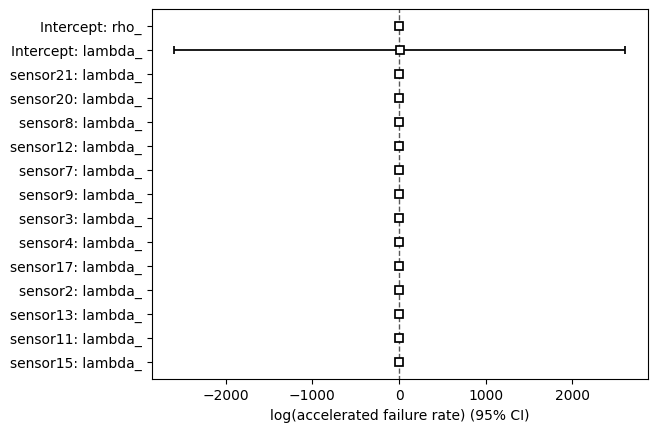

In [ ]:
aft.plot()

In [ ]:
import numpy as np
from collections import deque

# Model coefficients = AFT_Coef
BETA = {
    "sensor2": 0.91,
    "sensor3": 0.99,
    "sensor4": 0.96,
    "sensor7":  1.14,
    "sensor8":  1.60,
    "sensor9":  1.00,
    "sensor11": 0.42,
    "sensor12":  1.30,
    "sensor13": 0.61,
    "sensor15": 0.13,
    "sensor17": 0.92,
    "sensor20":  2.91,
    "sensor21":  3.52,
}

#sensors
FEATURES = list(BETA.keys())

#rolling stats for sensor pipeline
WINDOW = 50
risk_history = deque(maxlen=WINDOW)

def compute_risk_score(x):
    return sum(BETA[f] * x.get(f, 0) for f in FEATURES)

def compute_contributions(x):
    contrib = {f: BETA[f] * x.get(f, 0) for f in FEATURES}
    return contrib

def get_top_k(contrib, k=3):
    return sorted(contrib.items(), key=lambda x: abs(x[1]), reverse=True)[:k]


def detect_state(risk, mean, std):
    if std == 0:
        return "NORMAL"

    #z-score = variance from normal behavior
    z = (risk - mean) / std

    if z < 1:
        return "NORMAL"
    elif z < 2:
        return "WARNING"
    else:
        return "FAULT"


def generate_alert(state, top_features):
    if state == "NORMAL":
        return "System stable."

    msg = f"STATE: {state}\nTop drivers:\n"
    for f, v in top_features:
        if v > 0:
            msg += f" - {f}: hazardous effect\n"
        else:
            msg += f" + {f}: stabilising effect\n"
    return msg

def retrain_model(df):
    aft = WeibullAFTFitter()
    aft.fit(df, duration_col="time_cycles", event_col="breakdown")
    return aft

#sensor data stream
def process_stream(sensor_stream):

    aft_model = retrain_model(sensor_stream)

        # neue Koeffizienten extrahieren
    new_beta = aft.params_.loc["lambda_"].to_dict()

    for t, x in enumerate(sensor_stream):

        # 1. Risk
        risk = compute_risk_score(x)
        risk_history.append(risk)

        # 2. Stats
        mean = np.mean(risk_history)
        std = np.std(risk_history)

        # 3. State detection
        state = detect_state(risk, mean, std)

        # 4. Contributions
        contrib = compute_contributions(x)
        top_k = get_top_k(contrib, k=3)

        # 5. Alert
        alert = generate_alert(state, top_k)

        # 6. Output
        print("\n" + "="*50)
        print(f"TIME STEP: {t}")
        print(f"Risk score: {risk:.3f}")
        print(f"Mean: {mean:.3f} | Std: {std:.3f}")
        print(alert)


#data stream simulated
def df_stream(test_df):
    for _, row in test_df.iterrows():
        yield row.to_dict()

#run main
stream = df_stream(test)
process_stream(stream)

AttributeError: 'generator' object has no attribute 'copy'

#SHAPIQ

In [ ]:
!pip install shapiq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 82.6 MB/s eta 0:00:00


In [4]:
import joblib
import pandas as pd
import numpy as np

COLUMN_NAMES = [
    'unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]
SENSORS = [f"sensor_{i}" for i in range(1, 22)]

bundle = joblib.load('ano_model.joblib')

model          = bundle['model']
scalers        = bundle['scalers']
cluster_models = bundle['cluster_models']
feature_cols   = bundle['feature_cols']
window         = bundle['rolling_window']


data = pd.read_csv("train_FD001.txt", sep=r'\s+', header=None, names=COLUMN_NAMES)
data = data.sort_values(['unit_id', 'cycle']).reset_index(drop=True)

In [6]:
data["sensor_18"]

,sensor_18
0,2388
1,2388
2,2388
3,2388
4,2388
...,...
20626,2388
20627,2388
20628,2388
20629,2388


In [5]:
sensor_std = data[SENSORS].std()

print(sensor_std)

sensor_1     6.537152e-11
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     3.394700e-12
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    4.660829e-13
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    1.556432e-14
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64


In [146]:
data[SENSORS] = scalers[1].transform(data[SENSORS].astype(float))


In [157]:
data['cluster'] = cluster_models[2].predict(
    data[['op_setting_1', 'op_setting_2', 'op_setting_3']]
)
for cid in range(6):
    mask = data['cluster'] == cid
    if mask.sum():
        data.loc[mask, SENSORS] = scalers[2][cid].transform(
              data.loc[mask, SENSORS].astype(float)
        )

/tmp/ipykernel_853/1344102850.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.75709823 -1.46698662 -0.75709823 ...  2.08245531  2.08245531
  2.08245531]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mask, SENSORS] = scalers[2][cid].transform(


In [158]:
for engine in data['unit_id'].unique():
    mask = data['unit_id'] == engine
    for sensor in SENSORS:
        data.loc[mask, f'{sensor}_roll_mean'] = (
            data.loc[mask, sensor].rolling(window=window, min_periods=1).mean().values
        )
        data.loc[mask, f'{sensor}_roll_std'] = (
            data.loc[mask, sensor].rolling(window=window, min_periods=1).std().values
        )

# FIX: First std value is NaN — fill with 0
data.fillna(0, inplace=True)

# Predict anomaly scores and binary flags
print("Predicting anomalies...")
data['anomaly_score'] = model.decision_function(data[feature_cols])
data['is_anomaly']    = (model.predict(data[feature_cols]) == -1).astype(int)

Predicting anomalies...


In [159]:
anomalies = data[data["is_anomaly"] == 1]

In [160]:
X_sample = anomalies[feature_cols].sample(
    min(300, len(anomalies)),
    random_state=42
)
print(X_sample.shape)

(300, 42)


In [161]:
from shapiq import TreeExplainer

explainer = TreeExplainer(
    model=model,
    index="k-SII",
    max_order=2
)

In [162]:
interaction_values = explainer.explain_X(
    X_sample.values[:30]
)

first_order = np.array([
    iv.get_n_order_values(1)
    for iv in interaction_values
])

global_first = np.mean(np.abs(first_order), axis=0)

importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": global_first
    })
    .sort_values("importance", ascending=False)
)

importance.head(5)

second_order = np.array([
    iv.get_n_order_values(2)
    for iv in interaction_values
])

global_second = np.mean(
    np.abs(second_order),
    axis=0
)

##FD001

In [152]:
pairs = []

n = len(feature_cols)

for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "feature_1": feature_cols[i],
            "feature_2": feature_cols[j],
            "importance": global_second[i, j]
        })

pairs = (
    pd.DataFrame(pairs)
      .sort_values("importance", ascending=False)
)

pairs.head(20)

,feature_1,feature_2,importance
159,sensor_3_roll_mean,sensor_4_roll_mean,0.107959
98,sensor_2_roll_mean,sensor_11_roll_mean,0.068994
106,sensor_2_roll_mean,sensor_15_roll_mean,0.062715
773,sensor_15_roll_mean,sensor_17_roll_mean,0.058577
246,sensor_4_roll_mean,sensor_12_roll_mean,0.053102
435,sensor_7_roll_mean,sensor_12_roll_mean,0.050866
84,sensor_2_roll_mean,sensor_4_roll_mean,0.042711
248,sensor_4_roll_mean,sensor_13_roll_mean,0.042370
105,sensor_2_roll_mean,sensor_14_roll_std,0.040808
469,sensor_7_roll_std,sensor_15_roll_mean,0.040479


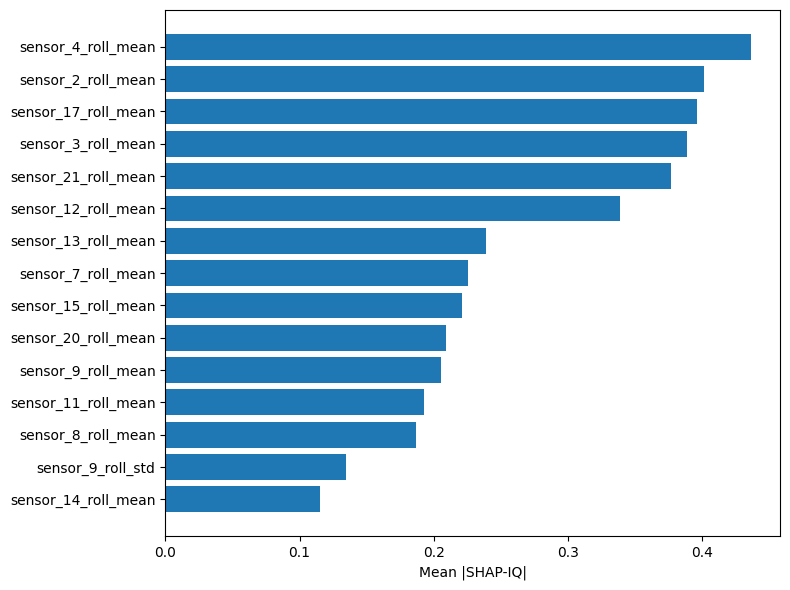

In [153]:
import matplotlib.pyplot as plt

top = importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP-IQ|")
plt.tight_layout()
plt.show()

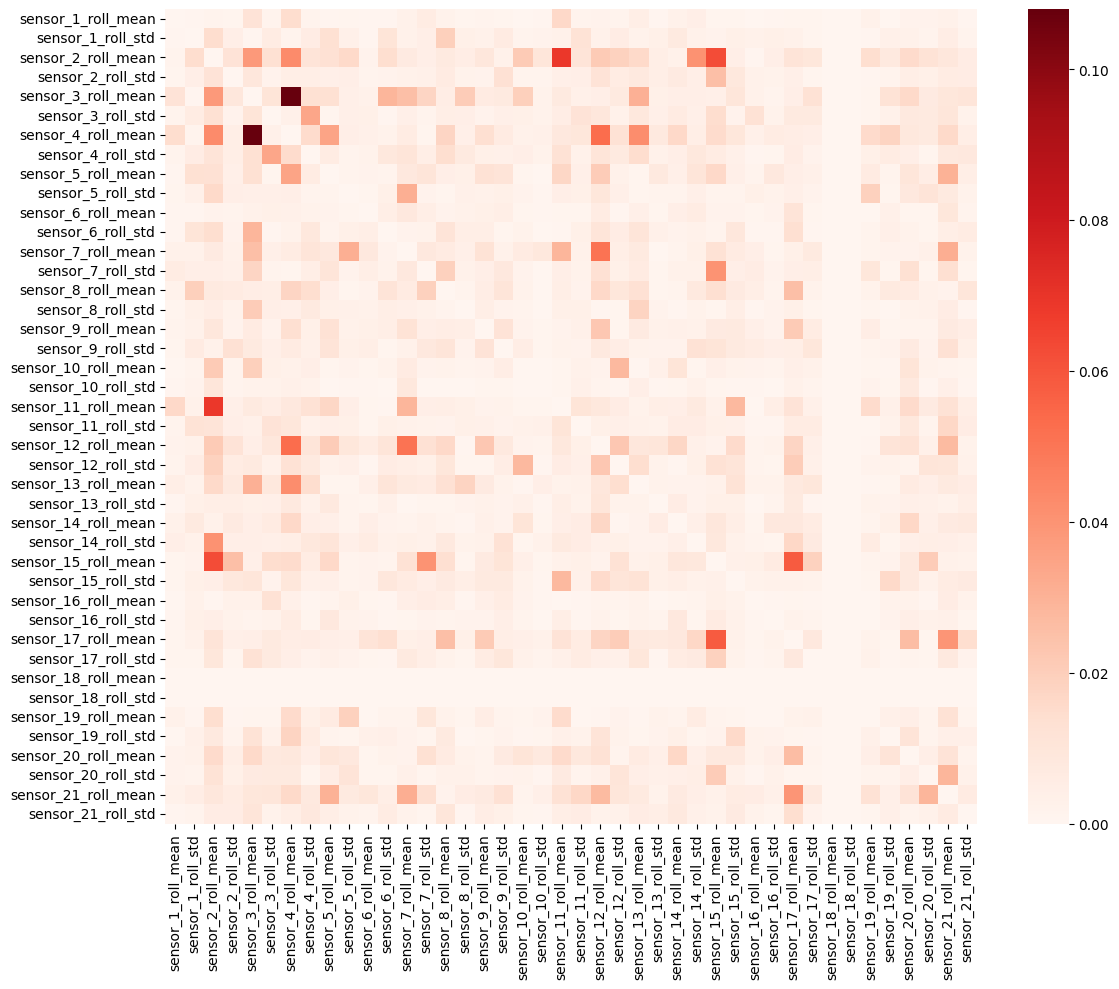

In [154]:
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    global_second,
    xticklabels=feature_cols,
    yticklabels=feature_cols,
    cmap="Reds"
)

plt.tight_layout()
plt.show()

##FD002

In [163]:
1pairs = []

n = len(feature_cols)

for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "feature_1": feature_cols[i],
            "feature_2": feature_cols[j],
            "importance": global_second[i, j]
        })

pairs = (
    pd.DataFrame(pairs)
      .sort_values("importance", ascending=False)
)

pairs.head(20)

,feature_1,feature_2,importance
679,sensor_12_roll_mean,sensor_16_roll_std,0.062985
159,sensor_3_roll_mean,sensor_4_roll_mean,0.058995
254,sensor_4_roll_mean,sensor_16_roll_mean,0.047572
795,sensor_16_roll_mean,sensor_16_roll_std,0.046556
773,sensor_15_roll_mean,sensor_17_roll_mean,0.043649
435,sensor_7_roll_mean,sensor_12_roll_mean,0.039414
106,sensor_2_roll_mean,sensor_15_roll_mean,0.038751
5,sensor_1_roll_mean,sensor_4_roll_mean,0.036063
804,sensor_16_roll_mean,sensor_21_roll_mean,0.034165
12,sensor_1_roll_mean,sensor_7_roll_std,0.033729


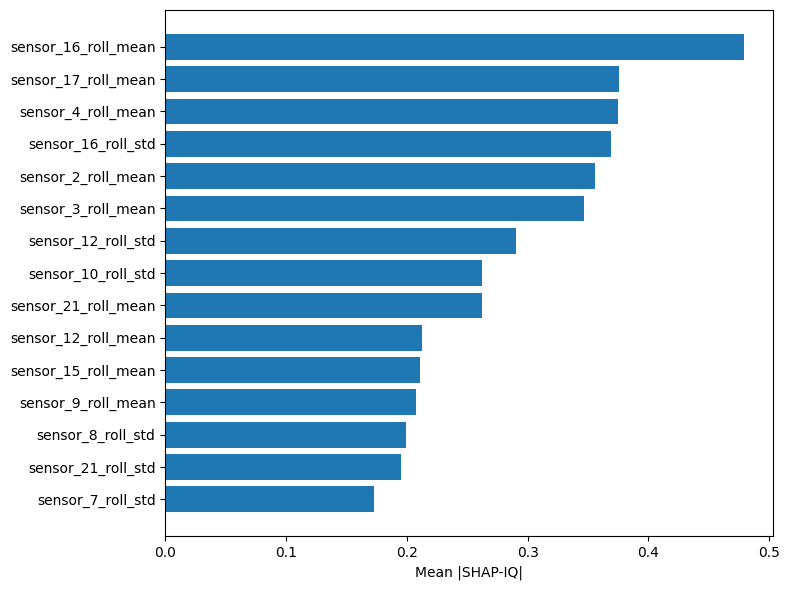

In [164]:
import matplotlib.pyplot as plt

top = importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP-IQ|")
plt.tight_layout()
plt.show()

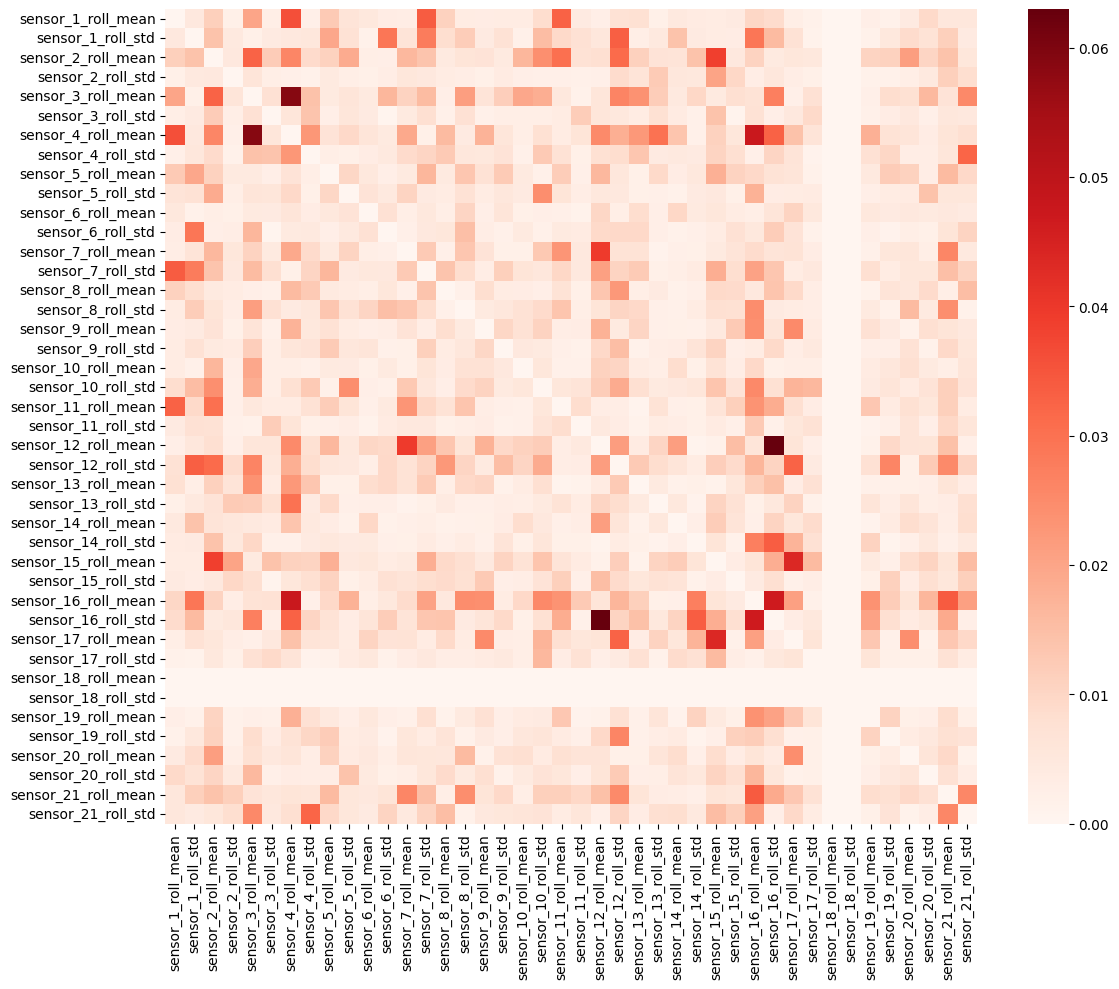

In [165]:
import seaborn as sns

plt.figure(figsize=(12,10))

sns.heatmap(
    global_second,
    xticklabels=feature_cols,
    yticklabels=feature_cols,
    cmap="Reds"
)

plt.tight_layout()
plt.show()